In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Задаём константы, которые будут использоваться при дальнейшей работе

In [11]:
DATASET_SIZE = 100

xs = np.linspace(0, 10, DATASET_SIZE)

NOISE_STD = 2
NOISE_BIAS = -1

BROKEN_DATASET_MULTIPLIER = 2

Создаём нормальные датасеты, выводим их "графики"

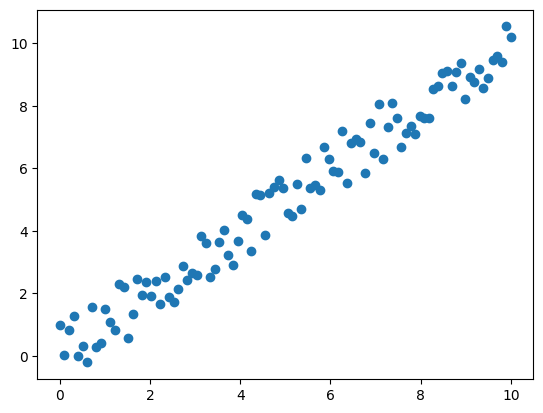

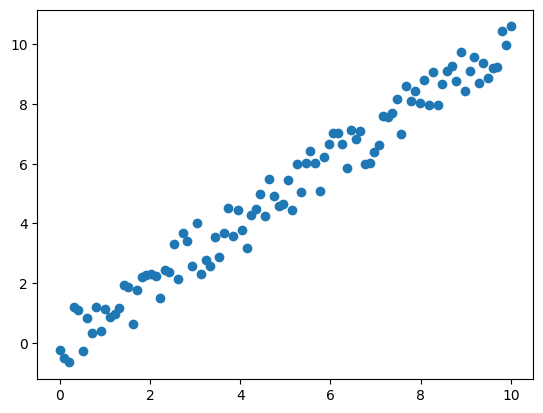

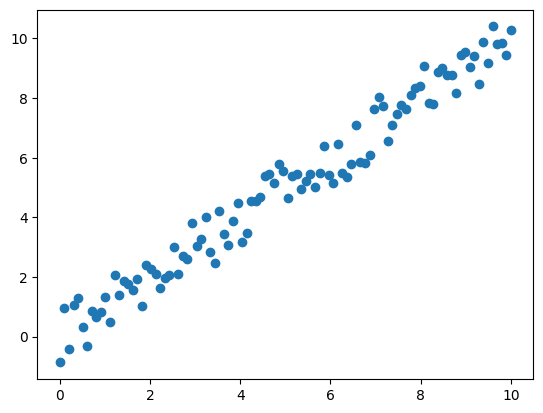

In [12]:
for i in range(1, 4):
    ys = xs + np.random.random(DATASET_SIZE) * NOISE_STD + NOISE_BIAS

    pd.DataFrame({'x': xs, 'y': ys}).to_csv(f'dataset_{i}.csv', index=False)

    plt.scatter(xs, ys)
    plt.show()

Обучаем модель на первом созданном датасете

In [13]:
from sklearn.linear_model import LinearRegression

df = pd.read_csv('dataset_1.csv')
model = LinearRegression()
model.fit(df[['x']], df['y'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Создаём "сломанный" датасет и выводим его графически

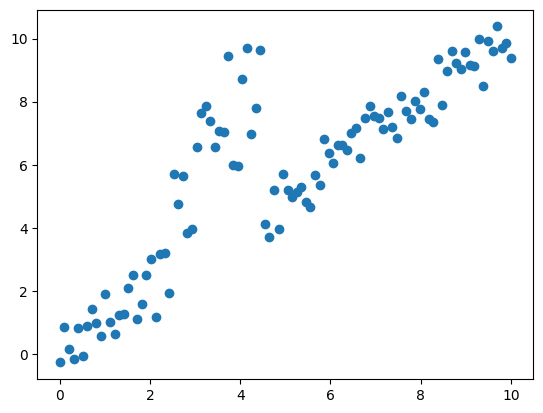

In [ ]:
ys = xs + np.random.random(100) * NOISE_STD + NOISE_BIAS
ys[25:45] *= BROKEN_DATASET_MULTIPLIER

pd.DataFrame({'x': xs, 'y': ys}).to_csv(f'dataset_broken.csv', index=False)

plt.scatter(xs, ys)
plt.show()

Создаём тест при помощи pytest + ipytest

Без ipytest не запустить pytest из ipynb (хотя мы почти уверены, что возможно, просто ipytest явно упрощает это действие)

Ниже делаем тест метрики R^2 - должен быть больше 0.8

Тест по последнему сломанному датасету должен упасть - такое будет ожидаемое поведение как "в проде".
Иными словами, мы сейчас притворяемся, что не знаем, что в датасетах есть "сломанный", и запускаем одинаковый тест на
все датасеты.

In [29]:
import ipytest
ipytest.autoconfig()

import pytest

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

@pytest.mark.parametrize(
    "file",
    [
        ("dataset_1.csv"),
        ("dataset_2.csv"),
        ("dataset_3.csv"),
        ("dataset_broken.csv"),
    ],
)
def test_quality(file):
    df = pd.read_csv(file)
    y_pred = model.predict(df[['x']])
    r2_val = r2(df['y'], y_pred)
    assert r2_val > 0.8, f"{file}: R^2={r2_val:.3f} (< 0.8)"

In [30]:
ipytest.run()

...F                                                                                         [100%]
============================================ FAILURES =============================================
________________________________ test_quality[dataset_broken.csv] _________________________________

file = 'dataset_broken.csv'

    @pytest.mark.parametrize(
        "file",
        [
            ("dataset_1.csv"),
            ("dataset_2.csv"),
            ("dataset_3.csv"),
            ("dataset_broken.csv"),
        ],
    )
    def test_quality(file):
        df = pd.read_csv(file)
        y_pred = model.predict(df[['x']])
        r2_val = r2(df['y'], y_pred)
>       assert r2_val > 0.8, f"{file}: R^2={r2_val:.3f} (< 0.8)"
E       AssertionError: dataset_broken.csv: R^2=0.672 (< 0.8)
E       assert np.float64(0.671729223345604) > 0.8

C:\Users\KRATOS\AppData\Local\Temp\ipykernel_47344\146223142.py:24: AssertionError
===================================== short test summary info ======

<ExitCode.TESTS_FAILED: 1>

Тест на сломанном датасете упал, как мы и ожидали